In [1]:
# Install the required libraries
# transformers -> provides the pretrained SegFormer model
# torch -> used for deep learning computations
# torchvision -> provides image-related utilities
# pillow -> used to open and process images
# matplotlib -> used to display images


In [3]:
# Upgrade pip first
!python -m pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 4.8 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 2.8 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.8 MB/s  0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


In [4]:
# Install the required libraries with a longer timeout
!pip install transformers torch torchvision pillow matplotlib --timeout 300 --retries 5

  Using cached torch-2.13.0-cp313-cp313-win_amd64.whl.metadata (39 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.8/122.1 MB 1.3 MB/s eta 0:01:35
   ---------------------------------------- 1.3/122.1 MB 1.7 MB/s eta 0:01:11
    --------------------------------------- 2.4/122.1 MB 2.7 MB/s eta 0:00:44
   - -------------------------------------- 3.1/122.1 MB 2.8 MB/s eta 0:00:43
   - -------------------------------------- 3.7/122.1 MB 3.0 MB/s eta 0:00:39
   - -------------------------------------- 4.5/122.1 MB 3.0 MB/s eta 0:00:40
   - -------------------------------------- 5.8/122.1 MB 3.4 MB/s eta 0:00:35
   -- ----------------------

  You can safely remove it manually.


In [5]:
# Import PyTorch for deep learning operations
import torch

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for displaying images
import matplotlib.pyplot as plt

# Import Image from PIL to read images
from PIL import Image

# Import the SegFormer image processor
from transformers import SegformerImageProcessor

# Import the pretrained SegFormer semantic segmentation model
from transformers import SegformerForSemanticSegmentation

In [6]:
# Name of the pretrained SegFormer model available on Hugging Face
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

# Load the image processor associated with the model
# It prepares the input image in the format expected by SegFormer
processor = SegformerImageProcessor.from_pretrained(model_name)

# Load the pretrained SegFormer semantic segmentation model
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

# Display a message to confirm that the model has been loaded
print("Pretrained SegFormer model loaded successfully!")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

C:\Users\shaik\anaconda3\envs\AakaashSirProjects\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shaik\.cache\huggingface\hub\models--nvidia--segformer-b0-finetuned-ade-512-512. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\shaik\anaconda3\envs\AakaashSirProjects\lib\site-packages\transformer

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Pretrained SegFormer model loaded successfully!


In [7]:
# Specify the path of the input image
image_path = "MP1.jpeg"

# Open the image using PIL
image = Image.open(image_path)

# Convert the image to RGB format
# RGB means Red, Green, and Blue color channels
image = image.convert("RGB")

# Display information about the image
print("Image loaded successfully!")

# Display the image size
print("Image size:", image.size)

Image loaded successfully!
Image size: (638, 480)


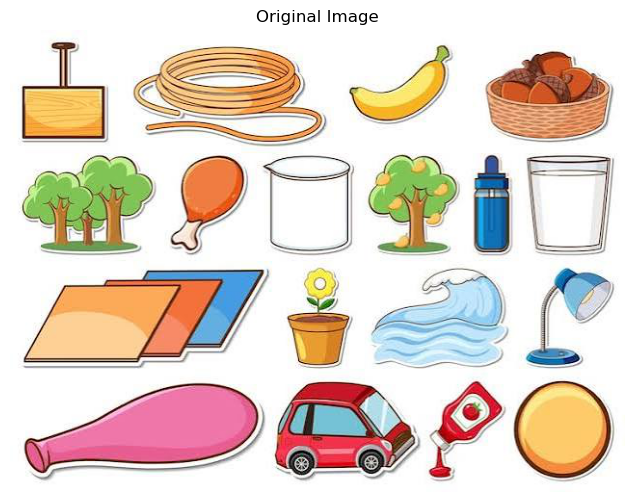

In [8]:
# Create a figure with a suitable size
plt.figure(figsize=(8, 6))

# Display the original image
plt.imshow(image)

# Add a title
plt.title("Original Image")

# Remove x-axis and y-axis
plt.axis("off")

# Display the figure
plt.show()

In [9]:
# Pass the image to the processor
# The processor converts the image into tensors
# that can be given to the deep learning model
inputs = processor(
    images=image,
    return_tensors="pt"
)

# Display confirmation
print("Image processed successfully!")

Image processed successfully!


In [10]:
# Disable gradient calculation because we are only predicting
# and not training the model
with torch.no_grad():

    # Pass the processed image to the pretrained model
    outputs = model(**inputs)

# Display confirmation
print("Segmentation prediction completed!")

Segmentation prediction completed!


In [11]:
# Get the raw segmentation predictions from the model
logits = outputs.logits

# Resize the model output to match the original image size
segmentation = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

# For every pixel, select the class with the highest prediction
segmentation = segmentation.argmax(dim=1)[0]

# Convert the PyTorch tensor into a NumPy array
segmentation = segmentation.cpu().numpy()

# Display confirmation
print("Segmentation mask created successfully!")

Segmentation mask created successfully!


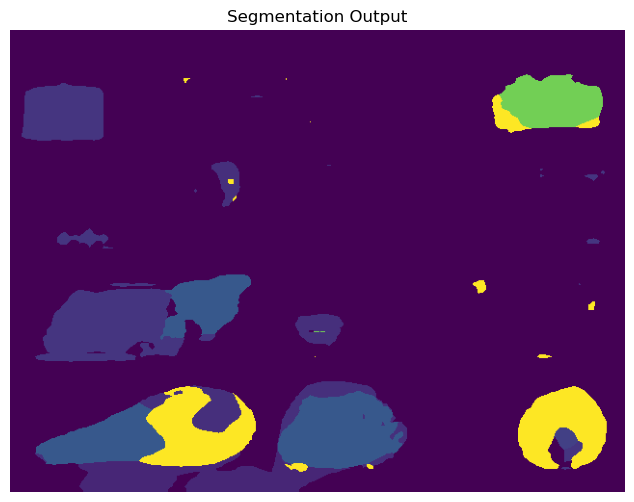

In [12]:
# Create a figure
plt.figure(figsize=(8, 6))

# Display the segmentation mask
plt.imshow(segmentation)

# Add title
plt.title("Segmentation Output")

# Hide the axes
plt.axis("off")

# Display the result
plt.show()

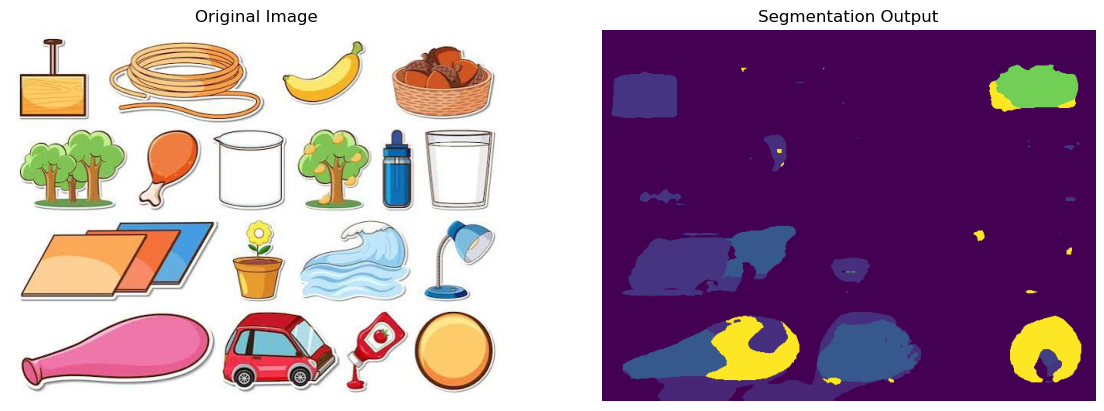

In [13]:
# Create a large figure
plt.figure(figsize=(14, 6))

# -------------------------------
# Display the original image
# -------------------------------

plt.subplot(1, 2, 1)

# Show original image
plt.imshow(image)

# Add title
plt.title("Original Image")

# Hide axes
plt.axis("off")


# -------------------------------
# Display segmentation output
# -------------------------------

plt.subplot(1, 2, 2)

# Show segmentation mask
plt.imshow(segmentation)

# Add title
plt.title("Segmentation Output")

# Hide axes
plt.axis("off")

# Display both images
plt.show()

In [14]:
# Get the mapping between class IDs and class names
id2label = model.config.id2label

# Find all unique class IDs present in the segmentation mask
unique_classes = np.unique(segmentation)

# Print a heading
print("Detected Segmented Classes:")
print("--------------------------------")

# Loop through every detected class
for class_id in unique_classes:

    # Get the class name using the class ID
    class_name = id2label[class_id]

    # Print the class ID and class name
    print(class_id, "->", class_name)

Detected Segmented Classes:
--------------------------------
0 -> wall
15 -> table
19 -> chair
22 -> painting
27 -> mirror
39 -> cushion
112 -> basket
142 -> plate


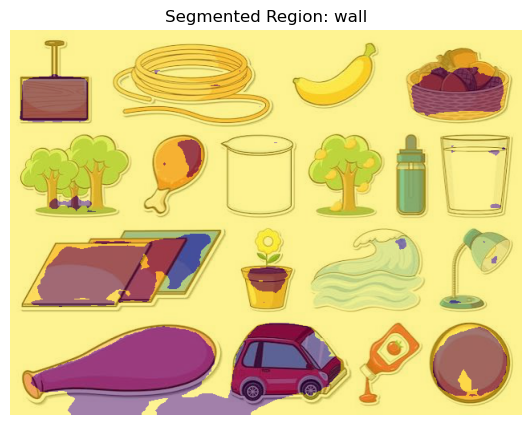

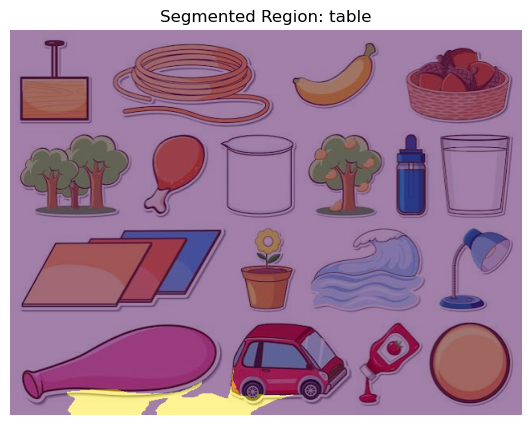

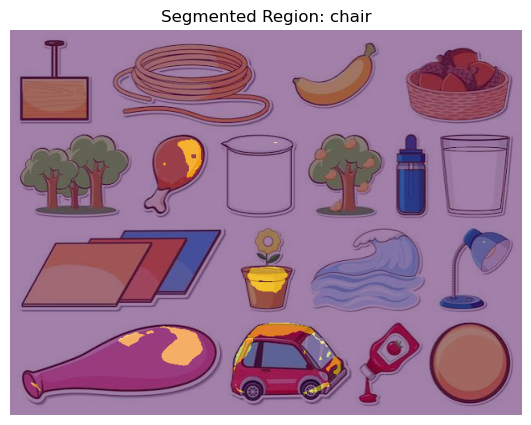

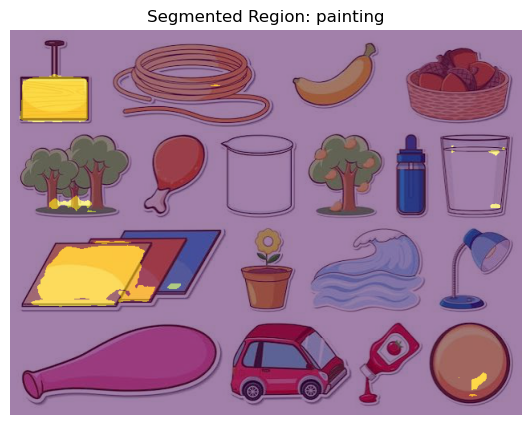

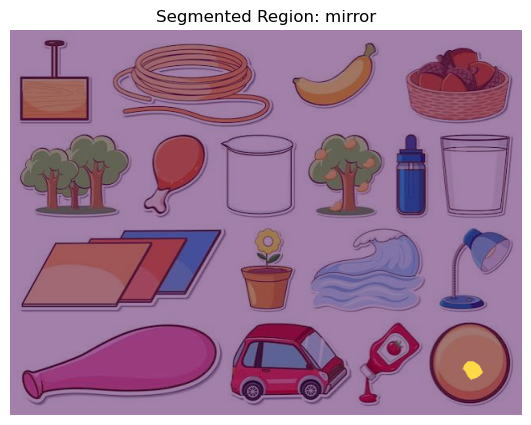

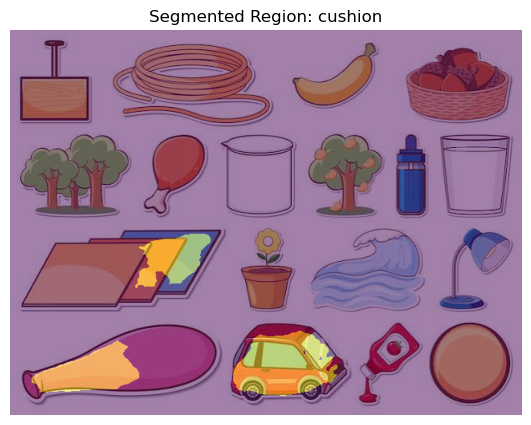

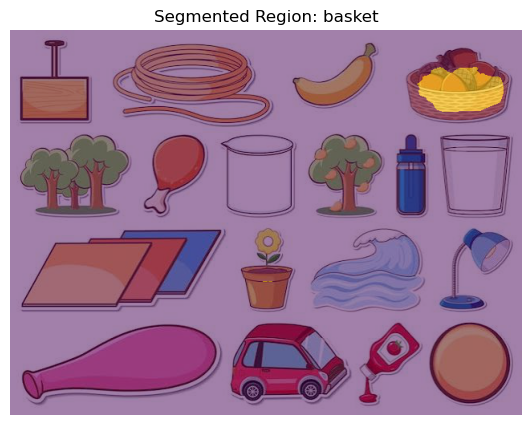

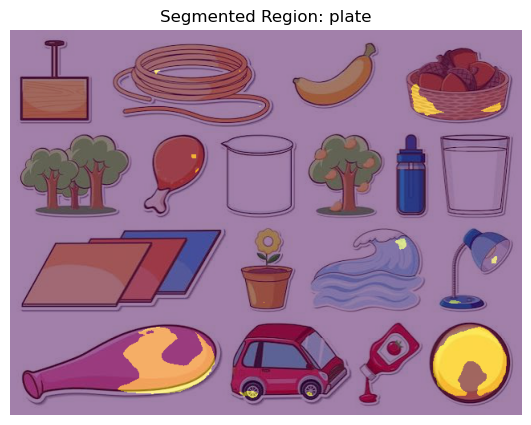

In [15]:
# Loop through every detected class
for class_id in unique_classes:

    # Get the name of the current class
    class_name = id2label[class_id]

    # Create a mask containing only the current class
    mask = segmentation == class_id

    # Create a new figure
    plt.figure(figsize=(7, 5))

    # Display the original image
    plt.imshow(image)

    # Overlay the selected segmented region
    # alpha controls the transparency
    plt.imshow(mask, alpha=0.5)

    # Add the class name as the title
    plt.title("Segmented Region: " + class_name)

    # Hide axes
    plt.axis("off")

    # Display the result
    plt.show()

In [ ]:
#---------------Conclusion------------------

#In this experiment, a pretrained SegFormer model from Hugging Face was used for semantic image segmentation.
#The model identified different objects and regions in the input images and generated pixel-level segmentation masks.
#Three different images were tested, and the successfully detected classes were identified. 
#This experiment demonstrates how pretrained deep learning models can perform image segmentation without training a model from scratch.